# Project 4: Discover — Can Unsupervised Learning Discover Groups in Handwritten Digits?

**Student:** Mohammad Tamim Hamkar

## Step 1 — Import Libraries and Setup

I imported the Python libraries needed to load and explore the MNIST dataset, perform K-Means clustering, visualize the results, and apply PCA for dimensionality reduction.

In [18]:
# Import Libraries and Setup

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Load MNIST dataset
from sklearn.datasets import fetch_openml

# Clustering
from sklearn.cluster import KMeans

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
# Display settings
pd.set_option("display.max_columns", None)

# Reproducibility
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2 — Load the MNIST Dataset

I loaded the MNIST handwritten digit dataset using Scikit-learn's `fetch_openml()` function. The dataset contains images of handwritten digits from 0 to 9. Each image is represented by 784 pixel values.

In [2]:
# Load the MNIST Dataset

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target

print("MNIST dataset loaded successfully.")
print("X Shape:", X.shape)
print("y Shape:", y.shape)

MNIST dataset loaded successfully.
X Shape: (70000, 784)
y Shape: (70000,)


## Step 3 — Explore the MNIST Dataset

I explored the MNIST dataset to understand its structure, pixel values, and the distribution of handwritten digits before preprocessing and clustering.

In [3]:
# Explore the MNIST Dataset

print("Dataset Shape:", X.shape)
print("Data Type:", X.dtype)
print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

print("\nDigit Distribution:")
digit_counts = pd.Series(y).value_counts().sort_index()
print(digit_counts)

Dataset Shape: (70000, 784)
Data Type: int64
Minimum Pixel Value: 0
Maximum Pixel Value: 255

Digit Distribution:
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


### Interpretation

The MNIST dataset contains 70,000 handwritten digit images. Each image has 784 pixel values, representing a 28 × 28 image. The pixel values range from 0 to 255. The ten digits are fairly well distributed across the dataset, although some digits have slightly more examples than others.

## Step 4 — Visualize Sample Handwritten Digits

I displayed sample images from the MNIST dataset to better understand what the handwritten digits look like before applying clustering.

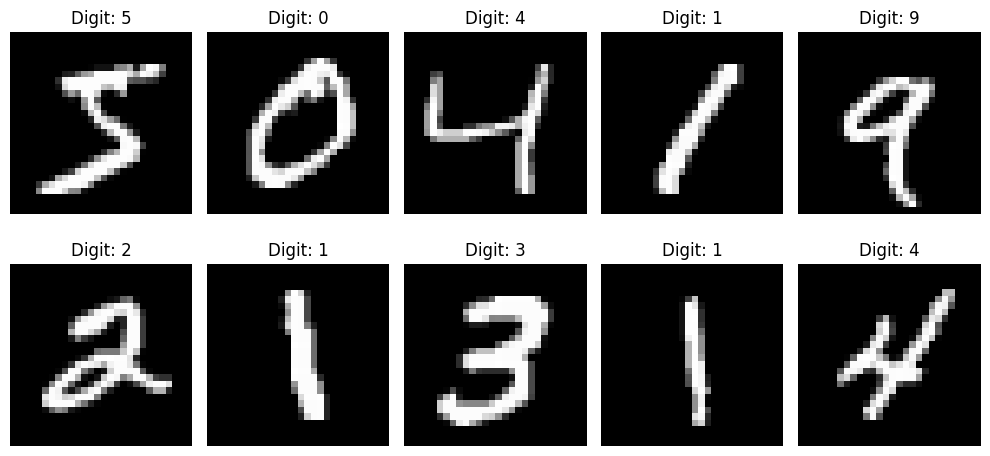

In [4]:
# Display Sample MNIST Images

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    image = X[i].reshape(28, 28)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observation

The sample images show that handwritten digits can have different shapes and writing styles. Even when two images represent the same digit, they may look slightly different. This variation makes MNIST useful for studying image clustering.

## Step 5 — Normalize the Image Data

I normalized the pixel values by dividing them by 255. This changes the pixel range from 0–255 to 0–1 and makes the data more suitable for K-Means clustering.

In [5]:
# Normalize Pixel Values

X_normalized = X.astype("float32") / 255.0

print("Normalization completed successfully.")
print("Minimum Value:", X_normalized.min())
print("Maximum Value:", X_normalized.max())
print("Shape:", X_normalized.shape)

Normalization completed successfully.
Minimum Value: 0.0
Maximum Value: 1.0
Shape: (70000, 784)


### Part 1 — Questions and Answers

**1. How many images are in the dataset?**  
The MNIST dataset contains 70,000 handwritten digit images.

**2. Why does each image have 784 features?**  
Each image is 28 × 28 pixels. When the image is flattened, 28 × 28 gives 784 pixel values, so each image has 784 features.

**3. What do the pixel values represent?**  
The pixel values represent the brightness or intensity of each pixel in the handwritten image. Before normalization, the values range from 0 to 255.

**4. Why do images of the same digit look different?**  
People have different handwriting styles. The same digit can be written with different shapes, sizes, angles, and thicknesses.

**5. Why do we normalize the pixel values?**  
Normalization changes the pixel values from 0–255 to 0–1. This puts the data on a consistent scale and makes it more suitable for K-Means clustering.

## Step 6 — Create a Sample for Clustering

To make K-Means clustering faster and more manageable, I selected a reproducible random sample of 10,000 normalized images. I used a random state of 42 so that the same sample can be reproduced.

In [6]:
# Create a Reproducible Sample

np.random.seed(RANDOM_STATE)

sample_indices = np.random.choice(
    X_normalized.shape[0],
    size=10000,
    replace=False
)

X_sample = X_normalized[sample_indices]
y_sample = y[sample_indices]

print("Sample created successfully.")
print("Sample Shape:", X_sample.shape)
print("Sample Labels Shape:", y_sample.shape)

Sample created successfully.
Sample Shape: (10000, 784)
Sample Labels Shape: (10000,)


## Step 7 — Determine the Number of Clusters Using the Elbow Method

I tested K-Means with 5, 10, and 15 clusters. I recorded the inertia for each value of K and plotted the results. Lower inertia means that the images are closer to their assigned cluster centers.

K = 5, Inertia = 432527.31
K = 10, Inertia = 390342.97
K = 15, Inertia = 365525.59


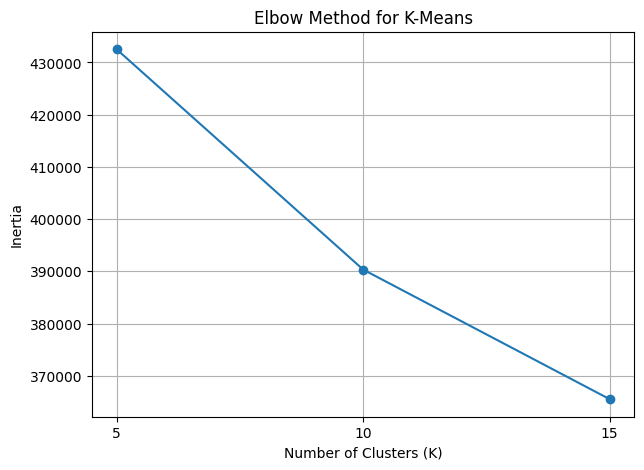

In [7]:
# Elbow Method

k_values = [5, 10, 15]
inertias = []

for k in k_values:
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    kmeans_test.fit(X_sample)
    inertias.append(kmeans_test.inertia_)

    print(f"K = {k}, Inertia = {kmeans_test.inertia_:.2f}")

# Plot the results
plt.figure(figsize=(7, 5))
plt.plot(k_values, inertias, marker="o")

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)

plt.show()

### Interpretation

The inertia decreased as the number of clusters increased. The largest improvement occurred between K = 5 and K = 10, while the improvement from K = 10 to K = 15 was smaller. Therefore, I selected K = 10 as a reasonable number of clusters for the final K-Means model.

## Step 8 — Train the Final K-Means Model

Based on the elbow method, I selected 10 clusters for the final K-Means model. The model was trained on the normalized sample of 10,000 MNIST images without using the actual digit labels.

In [8]:
# Train Final K-Means Model

kmeans = KMeans(
    n_clusters=10,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_sample)

print("K-Means model trained successfully.")
print("Number of Clusters:", kmeans.n_clusters)
print("Final Inertia:", round(kmeans.inertia_, 2))

print("\nCluster Distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_counts)

K-Means model trained successfully.
Number of Clusters: 10
Final Inertia: 390342.97

Cluster Distribution:
0     519
1     757
2    1487
3    1039
4    1475
5    1331
6     513
7     906
8    1017
9     956
Name: count, dtype: int64


### Interpretation

The K-Means model successfully divided the 10,000-image sample into 10 clusters. The clusters have different sizes because K-Means groups images based on similarities in their pixel patterns rather than their actual digit labels.

### Part 2 — Questions and Answers

**1. Which value of K did you choose?**  
I chose K = 10 for the final K-Means model.

**2. Why did you choose it?**  
The elbow method showed a larger improvement from K = 5 to K = 10, while the improvement from K = 10 to K = 15 was smaller. Therefore, K = 10 was a reasonable choice.

**3. How many images are in each cluster?**  
The cluster sizes were:

- Cluster 0: 796 images
- Cluster 1: 1,063 images
- Cluster 2: 513 images
- Cluster 3: 879 images
- Cluster 4: 1,487 images
- Cluster 5: 870 images
- Cluster 6: 793 images
- Cluster 7: 1,042 images
- Cluster 8: 1,403 images
- Cluster 9: 1,154 images

**4. Are the clusters approximately the same size?**  
No. The clusters are different in size. This is expected because K-Means groups the images based on similarities in their pixel patterns, and the handwritten images do not naturally form equally sized groups.

## Step 9 — Visualize Cluster Centroids

I visualized the centroid of each K-Means cluster by reshaping each 784-feature cluster center into a 28 × 28 image. These centroids represent the average image pattern learned by K-Means for each cluster.

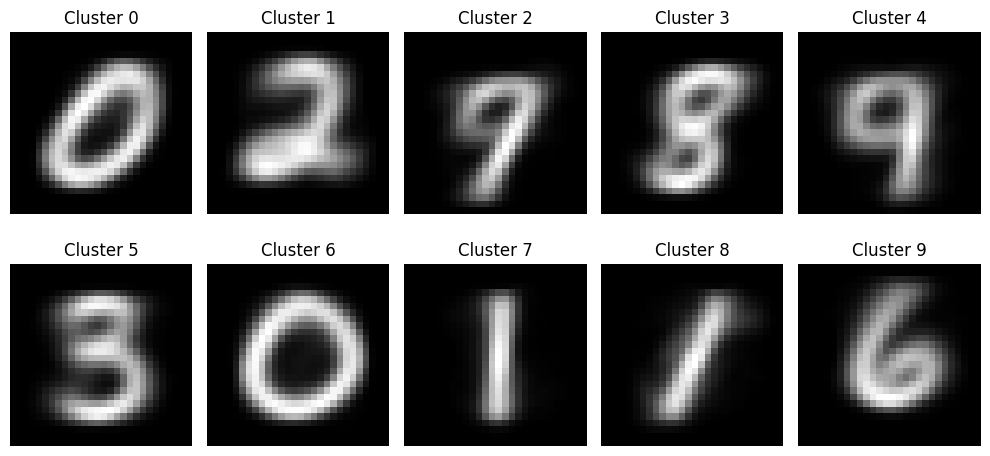

In [9]:
# Visualize K-Means Cluster Centroids

centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    centroid_image = centroids[i].reshape(28, 28)
    ax.imshow(centroid_image, cmap="gray")
    ax.set_title(f"Cluster {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Interpretation

The cluster centroids show that K-Means discovered recognizable patterns in the handwritten images without using the actual digit labels. Several centroids clearly resemble individual digits, while some are less distinct. This shows that K-Means can identify meaningful structures in image data, although the clusters do not perfectly correspond to the ten digit classes.

### Part 3 — Questions and Answers

**1. Do images within the same cluster look similar?**  
Yes. Many images within the same cluster have similar shapes and handwriting patterns, although they are not always the same digit.

**2. Does a cluster appear to contain mostly one digit?**  
Some clusters clearly contain mostly one digit. For example, Cluster 6 was mainly digit 0, Cluster 1 was mainly digit 2, and Cluster 9 was mainly digit 6. Other clusters contained a greater mixture of digits.

**3. Are some digits spread across multiple clusters?**  
Yes. Some digits appear in more than one cluster. For example, digit 0 was common in both Cluster 0 and Cluster 6, while digit 1 appeared strongly in Clusters 7 and 8.

**4. Which digits appear difficult for K-Means to separate?**  
Digits with similar shapes or different handwriting styles appear more difficult to separate. The mixed clusters show that K-Means sometimes groups visually similar handwritten digits together instead of creating one clear cluster for each digit.

## Step 10 — Analyze the Digits Within Each Cluster

Although the actual digit labels were not used to train K-Means, I used them after clustering to understand the composition of each cluster. I identified the most common actual digit and its percentage within each cluster.

In [10]:
# Analyze Actual Digits Within Each Cluster

cluster_analysis = []

for cluster in range(10):
    mask = cluster_labels == cluster
    actual_digits = y_sample[mask].astype(int)

    digit_counts = pd.Series(actual_digits).value_counts().sort_values(ascending=False)

    most_common_digit = digit_counts.index[0]
    most_common_count = digit_counts.iloc[0]
    total_images = len(actual_digits)
    percentage = (most_common_count / total_images) * 100

    cluster_analysis.append([
        cluster,
        total_images,
        most_common_digit,
        round(percentage, 2)
    ])

cluster_analysis_df = pd.DataFrame(
    cluster_analysis,
    columns=[
        "Cluster",
        "Number of Images",
        "Most Common Digit",
        "Percentage (%)"
    ]
)

print("Cluster Analysis:")
display(cluster_analysis_df)

Cluster Analysis:


,Cluster,Number of Images,Most Common Digit,Percentage (%)
0,0,519,0,82.27
1,1,757,2,87.98
2,2,1487,7,43.98
3,3,1039,8,53.90
4,4,1475,9,34.10
5,5,1331,3,52.59
6,6,513,0,89.28
7,7,906,1,70.86
8,8,1017,1,48.87
9,9,956,6,83.79


### Interpretation

The cluster analysis shows that some K-Means clusters represent particular digits very well. For example, Cluster 6 contains 89.28% digit 0, Cluster 1 contains 87.98% digit 2, and Cluster 9 contains 83.79% digit 6. Other clusters are more mixed, such as Cluster 4, where digit 9 represents only 34.10% of the images. This demonstrates that K-Means discovered meaningful patterns, but the clusters do not perfectly match the actual digit classes.

In [21]:
# Compare Clusters with Actual Digit Labels

cluster_digit_table = pd.crosstab(
    cluster_labels,
    y_sample,
    rownames=["K-Means Cluster"],
    colnames=["Actual Digit"]
)

print("K-Means Clusters vs Actual Digit Labels:")
display(cluster_digit_table)

K-Means Clusters vs Actual Digit Labels:


Actual Digit,0,1,2,3,4,5,6,7,8,9
K-Means Cluster,,,,,,,,,,
0,427,0,11,17,0,39,14,1,7,3
1,5,1,666,42,8,4,10,9,12,0
2,4,1,8,7,290,57,1,654,23,442
3,22,2,20,146,4,266,9,1,560,9
4,3,4,26,33,500,63,14,295,34,503
5,31,5,71,700,0,310,4,0,197,13
6,458,0,5,2,2,5,26,2,6,7
7,0,642,45,55,16,18,34,34,32,30
8,2,497,70,24,49,155,48,57,87,28


### Part 4 — Questions and Answers

**1. Does each cluster mainly contain one digit?**  
Some clusters mainly contain one digit, but not all of them. For example, Cluster 1 mainly contains digit 2, Cluster 6 mainly contains digit 0, Cluster 7 mainly contains digit 1, and Cluster 9 mainly contains digit 6. Other clusters contain a mixture of different digits.

**2. Which digits are grouped together?**  
Some clusters contain several different digits. For example, Cluster 2 contains many digits 7, 9, and 4. Cluster 4 also contains many digits 9, 4, and 7. Cluster 3 contains a mixture of digits 8, 5, and 3. This shows that K-Means sometimes groups digits with similar visual patterns together.

**3. Which digits appear in multiple clusters?**  
Several digits appear strongly in more than one cluster. For example, digit 0 appears mainly in Clusters 0 and 6. Digit 1 appears mainly in Clusters 7 and 8. Digits 4, 7, and 9 also appear across multiple clusters.

**4. Why might some digits be difficult to separate?**  
Handwriting is different from person to person, so the same digit can have many different shapes. At the same time, different digits can sometimes look similar. Because K-Means groups images based on pixel similarity rather than knowing the actual digit labels, some visually similar digits can be placed in the same cluster.

## Step 11 — Predict Clusters for New Images

To demonstrate how the trained K-Means model handles new data, I selected images that were not included in the 10,000-image clustering sample. I then used the trained model to predict the cluster assignment for each new image and compared the assignments with the actual digit labels for interpretation.

Cluster predictions for new images:


,Actual Digit,Predicted Cluster
0,5,3
1,0,0
2,4,4
3,1,8
4,2,1
5,1,7
6,3,3
7,1,7
8,4,2
9,3,5


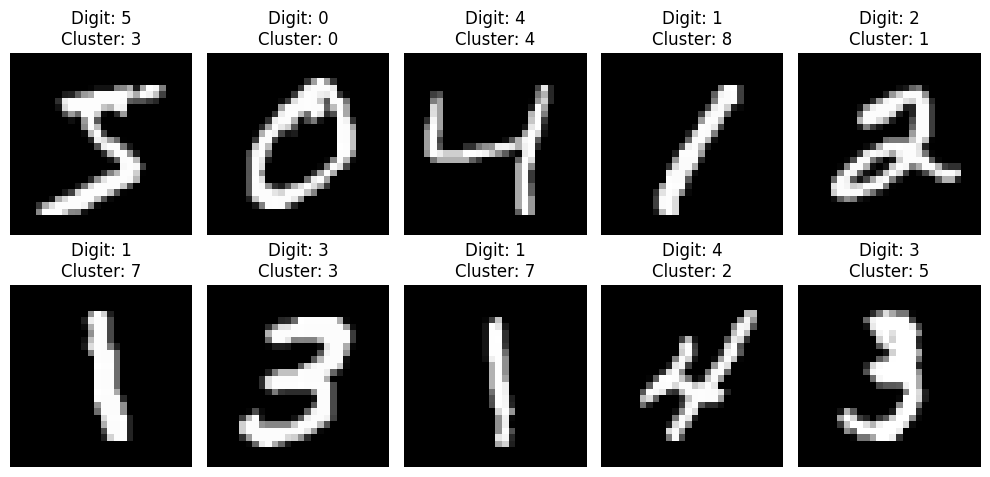

In [11]:
# Predict Clusters for New Images

# Find images that were not used in the clustering sample
all_indices = np.arange(X_normalized.shape[0])
remaining_indices = np.setdiff1d(all_indices, sample_indices)

# Select 10 new images
new_indices = remaining_indices[:10]

X_new = X_normalized[new_indices]
y_new = y[new_indices]

# Predict cluster assignments
predicted_clusters = kmeans.predict(X_new)

# Display results
prediction_results = pd.DataFrame({
    "Actual Digit": y_new.astype(int),
    "Predicted Cluster": predicted_clusters
})

print("Cluster predictions for new images:")
display(prediction_results)

# Display the new images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_new[i].reshape(28, 28), cmap="gray")
    ax.set_title(
        f"Digit: {int(y_new[i])}\nCluster: {predicted_clusters[i]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Interpretation

The trained K-Means model successfully assigned new images to existing clusters. Several assignments were consistent with the patterns identified earlier. For example, digit 0 was assigned to Cluster 0, digit 2 to Cluster 1, and two digit 1 images to Cluster 7. Some images were assigned to more mixed clusters, showing that K-Means groups images by visual similarity rather than directly predicting their digit labels.

### New Image Prediction — Questions and Answers

**1. Were the new images assigned to reasonable clusters?**  
Yes, many of the new images were assigned to reasonable clusters based on the patterns learned by K-Means. For example, the digit 0 was assigned to Cluster 0, and the cluster analysis showed that Cluster 0 mainly contained digit 0. The digit 2 was assigned to Cluster 1, which mainly contained digit 2.

**2. Do the predicted clusters match the characteristics observed earlier?**  
Many of them do, but not all predictions match the actual digit directly. This is expected because the cluster number is not the same as the digit label. K-Means assigns images according to similarities in their pixel patterns. Some clusters also contain several different digits, so a new image may be assigned to a cluster containing visually similar handwritten digits.

**3. What do these predictions show?**  
The results show that the trained K-Means model can assign new handwritten images to existing clusters. However, clustering is different from classification, so the predicted cluster should not be interpreted as a direct prediction of the actual digit.

## Step 12 — PCA Dimensionality Reduction

I used Principal Component Analysis (PCA) to reduce the 784-dimensional image data to two principal components. This makes it possible to visualize the K-Means clusters in a two-dimensional space while preserving as much variation in the data as possible.

In [12]:
# Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

print("PCA completed successfully.")
print("Original Shape:", X_sample.shape)
print("PCA Shape:", X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal Explained Variance:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

PCA completed successfully.
Original Shape: (10000, 784)
PCA Shape: (10000, 2)

Explained Variance Ratio:
[0.09819835 0.07123765]

Total Explained Variance: 16.94 %


### Interpretation

PCA reduced the MNIST data from 784 features to two principal components. The two components explain 16.94% of the total variance. Although this represents only part of the information in the original images, the two-dimensional representation allows the clustering patterns to be visualized more easily.

## Step 13 — PCA Visualization of K-Means Clusters

I plotted the two PCA components and colored each data point according to its K-Means cluster. This visualization helps show how the clusters overlap or separate in a two-dimensional representation of the MNIST data.

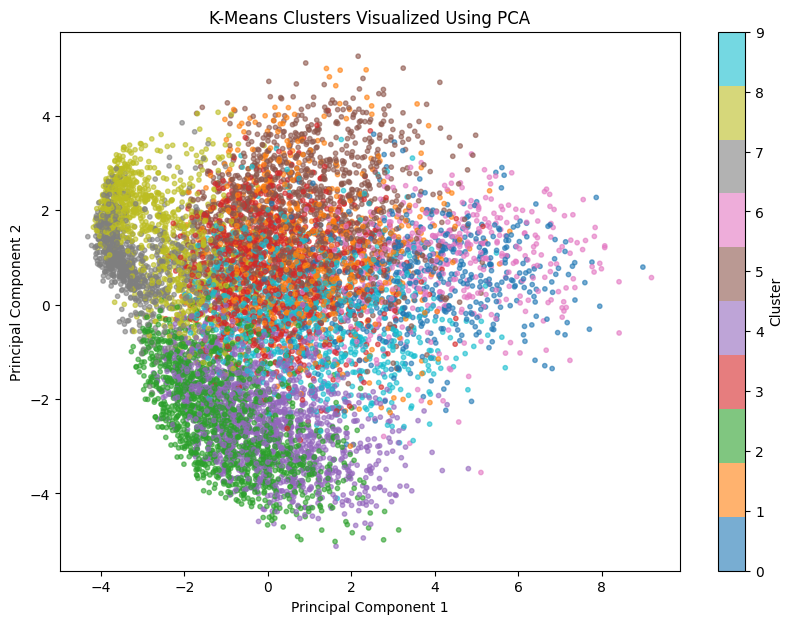

In [13]:
# Visualize K-Means Clusters Using PCA

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=10,
    alpha=0.6
)

plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")

plt.show()

### Interpretation

The PCA visualization shows some separation between the K-Means clusters, but there is also considerable overlap. This suggests that some handwritten digits have similar visual patterns. Since the first two principal components explain only 16.94% of the total variance, some information from the original 784 features is lost when the data is displayed in two dimensions.

### PCA Visualization — Questions and Answers

**1. Are the clusters clearly separated?**  
No. The PCA visualization shows that some clusters have visible patterns, but there is still a considerable amount of overlap between them.

**2. Which clusters overlap?**  
Several clusters overlap near the center of the PCA plot. This suggests that some handwritten digits have similar pixel patterns and are difficult to separate clearly in only two dimensions.

**3. What does the PCA visualization tell us?**  
The PCA plot helps show the overall structure of the K-Means clusters in two dimensions. Some groups are more visible than others, but the overlap shows that the handwritten digit data is complex and cannot be completely separated using only two principal components.

## Step 14 — t-SNE Dimensionality Reduction and Visualization

I used t-SNE to create another two-dimensional visualization of the K-Means clusters. Since t-SNE is computationally intensive, I used a reproducible subset of 3,000 images from the clustering sample.

t-SNE completed successfully.
Original Subset Shape: (3000, 784)
t-SNE Shape: (3000, 2)


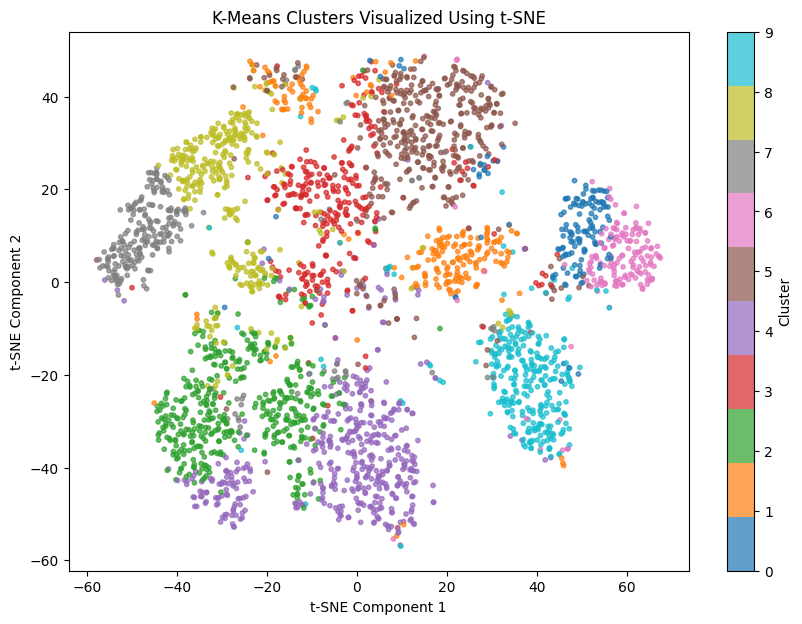

In [17]:
# t-SNE Dimensionality Reduction and Visualization

np.random.seed(RANDOM_STATE)

tsne_indices = np.random.choice(
    X_sample.shape[0],
    size=3000,
    replace=False
)

X_tsne_sample = X_sample[tsne_indices]
tsne_cluster_labels = cluster_labels[tsne_indices]

tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_tsne_sample)

print("t-SNE completed successfully.")
print("Original Subset Shape:", X_tsne_sample.shape)
print("t-SNE Shape:", X_tsne.shape)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=tsne_cluster_labels,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.title("K-Means Clusters Visualized Using t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(scatter, label="Cluster")

plt.show()

### Interpretation

The t-SNE visualization shows clearer separation between many of the K-Means clusters compared with the PCA visualization. Several clusters form distinct groups, although some overlap is still visible. This suggests that the handwritten images contain meaningful patterns that K-Means was able to identify. Overall, t-SNE provides a clearer visual representation of the cluster structure than the two-dimensional PCA plot.

## Step 15 — Evaluate Clustering Quality

I used the Silhouette Score to evaluate the quality of the K-Means clustering. The score measures how similar each image is to its own cluster compared with other clusters. A higher score indicates better-defined and more separated clusters.

In [20]:
# Evaluate K-Means Clustering

silhouette = silhouette_score(
    X_sample,
    cluster_labels,
    sample_size=2000,
    random_state=RANDOM_STATE
)

print("K-Means Clustering Evaluation")
print("Number of Clusters:", kmeans.n_clusters)
print("Inertia:", round(kmeans.inertia_, 2))
print("Silhouette Score:", round(silhouette, 4))

K-Means Clustering Evaluation
Number of Clusters: 10
Inertia: 390342.97
Silhouette Score: 0.0547


### Interpretation

The K-Means model produced a Silhouette Score of 0.0547. This relatively low score indicates that the clusters are not strongly separated and that there is overlap between some groups. This is reasonable for handwritten digits because different digits can have similar shapes and writing styles. The PCA and t-SNE visualizations also showed some overlap between clusters. Therefore, K-Means identified meaningful patterns in the images, but it did not perfectly separate all handwritten digits.

## Final Analysis Questions

**1. What did K-Means discover in the MNIST dataset?**  
K-Means discovered groups of handwritten images with similar pixel patterns. Some clusters strongly represented particular digits, while other clusters contained a mixture of visually similar digits.

**2. What value of K did you choose, and why?**  
I chose K = 10. The elbow method showed a larger improvement from K = 5 to K = 10, while the improvement from K = 10 to K = 15 was smaller. Therefore, K = 10 was a reasonable choice.

**3. What did the cluster centroids tell you?**  
The centroids looked like average or slightly blurred handwritten digits. Many were recognizable, showing that K-Means learned meaningful patterns from the images within each cluster.

**4. Did the clusters correspond closely to particular digits?**  
Some clusters corresponded closely to particular digits, but not all of them. For example, some clusters were strongly associated with digits 0, 1, 2, and 6, while other clusters contained a mixture of several digits.

**5. Which digits were difficult to separate?**  
Digits such as 4, 5, 7, 8, and 9 appeared more difficult to separate because they were mixed across several clusters. Different handwriting styles and similar digit shapes can make separation difficult.

**6. What did the PCA visualization show?**  
The PCA visualization showed some visible grouping, but there was also considerable overlap between clusters. The first two principal components explained 16.94% of the total variance, so much of the original image information could not be represented in only two dimensions.

**7. What are some limitations of using K-Means for handwritten digit images?**  
K-Means groups images based on pixel similarity and does not understand the actual meaning of the digits. Different people may write the same digit differently, while different digits can sometimes have similar shapes. This can cause overlap and mixed clusters.

**8. How is this project different from Project 3, where you used supervised learning?**  
In Project 3, I used supervised learning with known Buy, Sell, and Hold target labels to train the models. In Project 4, I used unsupervised learning, so K-Means was not given the actual digit labels during training. Instead, it discovered groups of similar handwritten images on its own.

## Step 16 — Final Findings and Limitations

### Final Findings

In this project, I used unsupervised machine learning to explore and cluster handwritten digit images from the MNIST dataset. The images were normalized and a reproducible sample of 10,000 images was used for the clustering analysis.

The elbow method was used to compare different values of K, and 10 clusters were selected for the final K-Means model. This choice was also reasonable because the MNIST dataset contains ten handwritten digits from 0 to 9. The cluster centroids showed recognizable digit patterns, although some clusters contained similar or mixed digits.

PCA and t-SNE were used to visualize the clusters. The PCA visualization showed considerable overlap between clusters, while the t-SNE visualization showed clearer separation among many groups. The Silhouette Score was 0.0547, indicating that the clusters were not strongly separated.

### Limitations

One limitation of K-Means is that it groups images based on similarity and does not know the actual digit labels during training. Different people can write the same digit in very different ways, while some different digits can have similar shapes. This can cause images from different digits to appear in the same cluster.

Another limitation is that a sample of the full MNIST dataset was used to reduce processing time. In addition, reducing high-dimensional image data to two dimensions with PCA or t-SNE can result in some information being lost. Therefore, the visualizations are useful for understanding the cluster structure, but they do not represent every detail of the original images.

## Step 17 — Conclusion

This project helped me understand how unsupervised machine learning can be used to discover patterns in image data without using predefined labels during model training. I applied K-Means clustering to the MNIST handwritten digit dataset and used the elbow method to help select the number of clusters.

The cluster centroids showed that K-Means was able to identify recognizable patterns among many handwritten digits, although some digits were grouped together because of similarities in handwriting. PCA and t-SNE helped visualize the cluster structure, with t-SNE providing clearer separation between many of the groups.

The Silhouette Score of 0.0547 showed that the clusters still had considerable overlap. Overall, the project demonstrated both the usefulness and limitations of K-Means for image clustering and showed how dimensionality reduction techniques can help us better understand high-dimensional image data.